In [35]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np

In [44]:


def pair_trading_strategy(file_voo, file_spy):
    # Load dataset
    os.chdir('C:/Users/eugen/')
    data_voo = pd.read_csv(file_voo)
    data_spy = pd.read_csv(file_spy)

    close_voo = data_voo['close']
    close_spy = data_spy['close']

    # Align indices to ensure all series have the same length
    close_voo, close_spy = close_voo.align(close_spy, join='inner')

    # Calculate the spread (price difference) between VOO and SPY
    spread = close_voo - close_spy

    # Calculate z-score for the spread
    zscore = (spread - spread.mean()) / spread.std()

    # Define entry and exit signals based on z-score thresholds
    entry_zscore = -2
    exit_zscore = 0

    long_signal = (zscore < entry_zscore) & (zscore.shift(1) > entry_zscore)
    short_signal = (zscore > -entry_zscore) & (zscore.shift(1) < -entry_zscore)

    # Initialize variables for backtesting
    initial_capital = 10000  # Initial capital
    cash = initial_capital
    voo_shares = 0
    spy_shares = 0
    total_value = []

    # Prepare to collect trade logs
    trade_logs = []

    for i in range(len(spread)):
        action = 'Hold'
        voo_shares_change = 0
        spy_shares_change = 0
        
        if long_signal[i]:
            action = 'Long VOO & Short SPY'
            voo_shares_to_buy = cash / close_voo.iloc[i]
            spy_shares_to_sell = voo_shares_to_buy
            cash -= voo_shares_to_buy * close_voo.iloc[i]
            cash += spy_shares_to_sell * close_spy.iloc[i]
            voo_shares += voo_shares_to_buy
            spy_shares -= spy_shares_to_sell
            voo_shares_change = voo_shares_to_buy
            spy_shares_change = -spy_shares_to_sell
        elif short_signal[i]:
            action = 'Short VOO & Long SPY'
            voo_shares_to_sell = voo_shares
            spy_shares_to_buy = voo_shares_to_sell
            cash += voo_shares_to_sell * close_voo.iloc[i]
            cash -= spy_shares_to_buy * close_spy.iloc[i]
            voo_shares -= voo_shares_to_sell
            spy_shares += spy_shares_to_buy
            voo_shares_change = -voo_shares_to_sell
            spy_shares_change = spy_shares_to_buy
        
        total_portfolio_value = cash + voo_shares * close_voo.iloc[i] + spy_shares * close_spy.iloc[i]
        total_value.append(total_portfolio_value)
        profit_loss = total_portfolio_value - initial_capital

        # Collect data for the trade log
        trade_logs.append({
            'Timestamp': data_voo.index[i],  # Adjust if the index is not the timestamp
            'Action': action,
            'VOO_Shares': voo_shares_change,
            'SPY_Shares': spy_shares_change,
            'Cash': cash,
            'P/L': profit_loss
        })

    # Convert the collected trade logs into a DataFrame
    trade_log = pd.DataFrame(trade_logs)

    # Print the trade log
    print(trade_log)

    # Plotting the total portfolio value over time
    plt.figure(figsize=(10, 6))
    plt.plot(total_value, color='blue')
    plt.title('Total Portfolio Value Over Time')
    plt.xlabel('Time')
    plt.ylabel('Total Portfolio Value')
    plt.grid(True)
    plt.show()

      Timestamp Action  VOO_Shares  SPY_Shares          Cash          P/L
0             0   Hold         0.0         0.0  10000.000000     0.000000
1             1   Hold         0.0         0.0  10000.000000     0.000000
2             2   Hold         0.0         0.0  10000.000000     0.000000
3             3   Hold         0.0         0.0  10000.000000     0.000000
4             4   Hold         0.0         0.0  10000.000000     0.000000
...         ...    ...         ...         ...           ...          ...
5454       5454   Hold         0.0         0.0  26212.717433  4159.662439
5455       5455   Hold         0.0         0.0  26212.717433  4066.200038
5456       5456   Hold         0.0         0.0  26212.717433  4051.821207
5457       5457   Hold         0.0         0.0  26212.717433  4015.874130
5458       5458   Hold         0.0         0.0  26212.717433  3997.900591

[5459 rows x 6 columns]


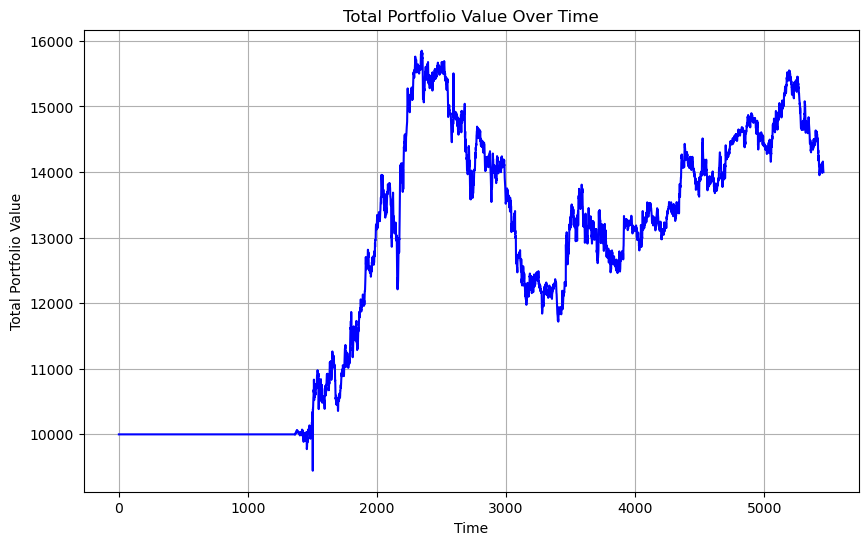

In [46]:
pair_trading_strategy("dataset/VOO_1min_sample.csv","dataset/SPY_1min_sample.csv")

      Timestamp Action  VOO_Shares  SPY_Shares          Cash         P/L
0             0   Hold         0.0         0.0  10000.000000    0.000000
1             1   Hold         0.0         0.0  10000.000000    0.000000
2             2   Hold         0.0         0.0  10000.000000    0.000000
3             3   Hold         0.0         0.0  10000.000000    0.000000
4             4   Hold         0.0         0.0  10000.000000    0.000000
...         ...    ...         ...         ...           ...         ...
1396       1396   Hold         0.0         0.0  10754.655468  754.655468
1397       1397   Hold         0.0         0.0  10754.655468  754.655468
1398       1398   Hold         0.0         0.0  10754.655468  754.655468
1399       1399   Hold         0.0         0.0  10754.655468  754.655468
1400       1400   Hold         0.0         0.0  10754.655468  754.655468

[1401 rows x 6 columns]


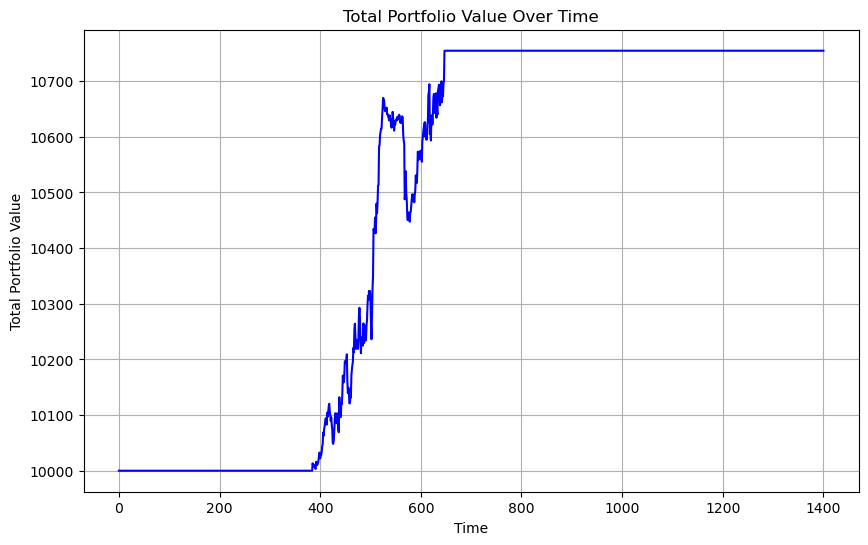

In [47]:
pair_trading_strategy("dataset/VOO_5min_sample.csv","dataset/SPY_5min_sample.csv")

     Timestamp Action  VOO_Shares  SPY_Shares          Cash         P/L
0            0   Hold         0.0         0.0  10000.000000    0.000000
1            1   Hold         0.0         0.0  10000.000000    0.000000
2            2   Hold         0.0         0.0  10000.000000    0.000000
3            3   Hold         0.0         0.0  10000.000000    0.000000
4            4   Hold         0.0         0.0  10000.000000    0.000000
..         ...    ...         ...         ...           ...         ...
297        297   Hold         0.0         0.0  11466.459373  534.454806
298        298   Hold         0.0         0.0  11466.459373  561.791753
299        299   Hold         0.0         0.0  11466.459373  547.891611
300        300   Hold         0.0         0.0  11466.459373  546.761066
301        301   Hold         0.0         0.0  11466.459373  532.601454

[302 rows x 6 columns]


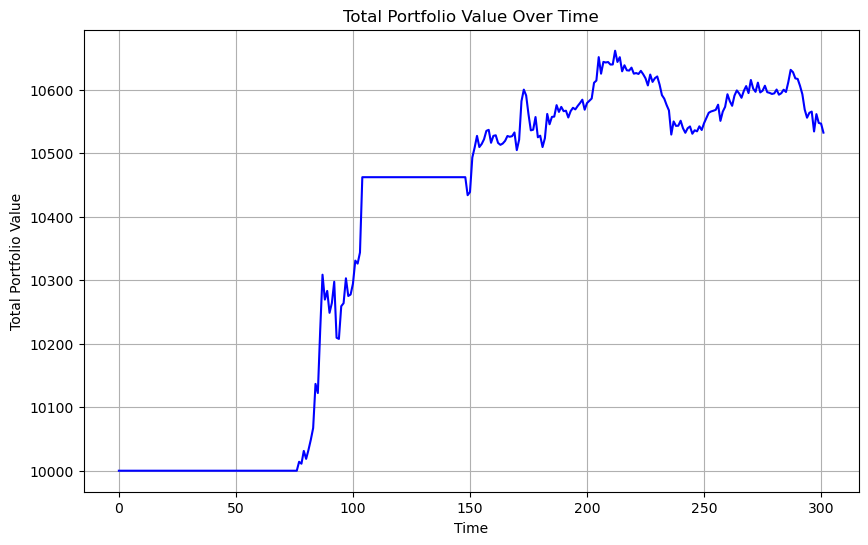

In [48]:
pair_trading_strategy("dataset/VOO_30min_sample.csv","dataset/SPY_30min_sample.csv")

     Timestamp Action  VOO_Shares  SPY_Shares          Cash         P/L
0            0   Hold         0.0         0.0  10000.000000    0.000000
1            1   Hold         0.0         0.0  10000.000000    0.000000
2            2   Hold         0.0         0.0  10000.000000    0.000000
3            3   Hold         0.0         0.0  10000.000000    0.000000
4            4   Hold         0.0         0.0  10000.000000    0.000000
..         ...    ...         ...         ...           ...         ...
159        159   Hold         0.0         0.0  10512.983502  512.983502
160        160   Hold         0.0         0.0  10512.983502  512.983502
161        161   Hold         0.0         0.0  10512.983502  512.983502
162        162   Hold         0.0         0.0  10512.983502  512.983502
163        163   Hold         0.0         0.0  10512.983502  512.983502

[164 rows x 6 columns]


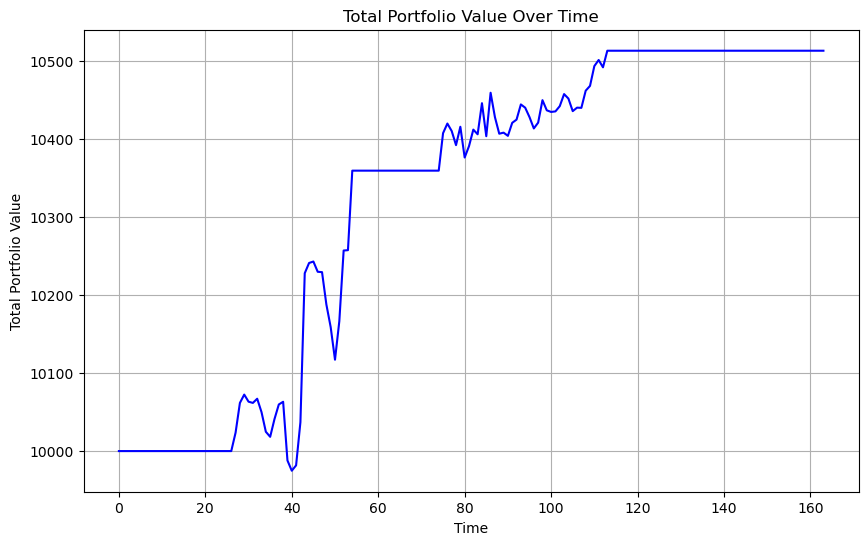

In [49]:
pair_trading_strategy("dataset/VOO_1hour_sample.csv","dataset/SPY_1hour_sample.csv")

    Timestamp                Action  VOO_Shares  SPY_Shares     Cash  P/L
0           0                  Hold           0           0  10000.0  0.0
1           1                  Hold           0           0  10000.0  0.0
2           2  Short VOO & Long SPY           0           0  10000.0  0.0
3           3                  Hold           0           0  10000.0  0.0
4           4                  Hold           0           0  10000.0  0.0
5           5                  Hold           0           0  10000.0  0.0
6           6                  Hold           0           0  10000.0  0.0
7           7                  Hold           0           0  10000.0  0.0
8           8                  Hold           0           0  10000.0  0.0
9           9                  Hold           0           0  10000.0  0.0
10         10                  Hold           0           0  10000.0  0.0


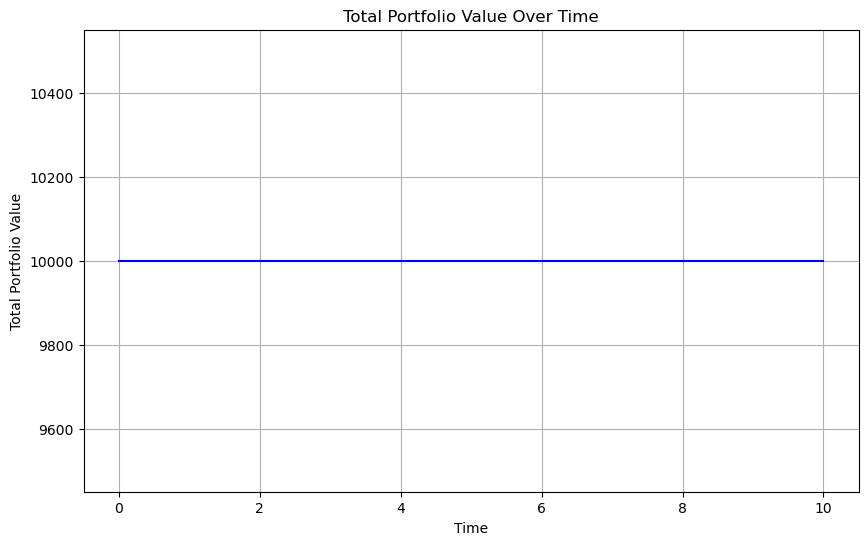

In [50]:
pair_trading_strategy("dataset/VOO_1day_sample.csv","dataset/SPY_1day_sample.csv")